In [1]:
# Install required packages
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn torch transformers
!pip install nltk textblob googletrans==4.0.0-rc1
!pip install beautifulsoup4 requests pandas_datareader
!pip install ta  # Technical Analysis library
!pip install wordcloud

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import re
from textblob import TextBlob
from googletrans import Translator
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, classification_report, confusion_matrix
import ta
from ta import add_all_ta_features
from ta.utils import dropna
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('vader_lexicon')
nltk.download('punkt')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
class IndianMarketDataCollector:
    """Collects multi-source data for Indian stock market analysis"""

    def __init__(self):
        self.translator = Translator()
        self.sid = SentimentIntensityAnalyzer()

    def get_stock_data(self, ticker, start_date='2018-01-01', end_date='2024-12-31'):
        """Fetch stock data for Indian companies"""
        # Indian stock tickers on Yahoo Finance
        indian_tickers = {
            'RELIANCE': 'RELIANCE.NS',  # Reliance Industries
            'TCS': 'TCS.NS',            # Tata Consultancy Services
            'HDFCBANK': 'HDFCBANK.NS',  # HDFC Bank
            'INFY': 'INFY.NS',          # Infosys
            'ICICIBANK': 'ICICIBANK.NS',# ICICI Bank
            'SBIN': 'SBIN.NS',          # State Bank of India
            'BHARTIARTL': 'BHARTIARTL.NS', # Bharti Airtel
            'ITC': 'ITC.NS',            # ITC Limited
            'HINDUNILVR': 'HINDUNILVR.NS', # Hindustan Unilever
            'AXISBANK': 'AXISBANK.NS',  # Axis Bank
            'NIFTY50': '^NSEI',         # Nifty 50 Index
            'SENSEX': '^BSESN'          # BSE Sensex
        }

        yahoo_ticker = indian_tickers.get(ticker, f"{ticker}.NS")
        data = yf.download(yahoo_ticker, start=start_date, end=end_date, progress=False)

        # Handle empty download result
        if data is None or data.empty:
            raise ValueError(f"No data returned for {yahoo_ticker} between {start_date} and {end_date}")

        # If yfinance returned MultiIndex columns (e.g., when multiple tickers), simplify
        if isinstance(data.columns, pd.MultiIndex):
            level0 = data.columns.get_level_values(0)
            if yahoo_ticker in level0:
                data = data.xs(yahoo_ticker, axis=1, level=0)
            else:
                data.columns = data.columns.get_level_values(-1)

        # Coerce expected columns to numeric safely
        for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
            if col in data.columns:
                data[col] = pd.to_numeric(data[col], errors='coerce')
            else:
                data[col] = np.nan

        # Calculate returns after ensuring numeric types
        if 'Close' in data.columns:
            data['Returns'] = data['Close'].pct_change()
            data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
        else:
            data['Returns'] = np.nan
            data['Log_Returns'] = np.nan

        # Add technical indicators using TA library
        # Use fillna=True to let the library handle initial NaNs, then dropna afterwards
        data = add_all_ta_features(
            data, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=True
        )

        # Drop any remaining NaN values after adding all technical features
        data.dropna(inplace=True)

        # Add custom technical indicators
        data['SMA_20'] = data['Close'].rolling(window=20).mean()
        data['SMA_50'] = data['Close'].rolling(window=50).mean()
        data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
        data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
        data['RSI'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()

        # MACD
        exp1 = data['Close'].ewm(span=12, adjust=False).mean()
        exp2 = data['Close'].ewm(span=26, adjust=False).mean()
        data['MACD'] = exp1 - exp2
        data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

        # Bollinger Bands
        data['BB_Middle'] = data['Close'].rolling(window=20).mean()
        bb_std = data['Close'].rolling(window=20).std()
        data['BB_Upper'] = data['BB_Middle'] + (bb_std * 2)
        data['BB_Lower'] = data['BB_Middle'] - (bb_std * 2)

        # Volume indicators
        data['Volume_SMA'] = data['Volume'].rolling(window=20).mean()
        data['Volume_Ratio'] = data['Volume'] / data['Volume_SMA']

        return data

    def fetch_indian_news(self, query='stock market India', days_back=30):
        """Fetch Indian financial news from Moneycontrol"""
        print(f"Fetching Indian financial news for: {query}")

        # Sample news data (in practice, you would scrape from Moneycontrol/ET)
        news_data = []

        # Moneycontrol RSS feed URLs for different categories
        news_sources = {
            'markets': 'https://www.moneycontrol.com/rss/marketreports.xml',
            'business': 'https://www.moneycontrol.com/rss/business.xml',
            'economy': 'https://www.moneycontrol.com/rss/economy.xml'
        }

        for category, url in news_sources.items():
            try:
                response = requests.get(url, timeout=10)
                soup = BeautifulSoup(response.content, 'xml')
                items = soup.find_all('item')[:10]  # Limit to 10 per category

                for item in items:
                    title = item.find('title').text if item.find('title') else ''
                    description = item.find('description').text if item.find('description') else ''
                    pub_date = item.find('pubDate').text if item.find('pubDate') else ''

                    news_data.append({
                        'date': pd.to_datetime(pub_date),
                        'title': title,
                        'content': description,
                        'source': 'Moneycontrol',
                        'category': category
                    })
            except Exception as e:
                print(f"Error fetching {category} news: {e}")
                # Generate synthetic news for demonstration
                dates = pd.date_range(end=datetime.now(), periods=100, freq='D')
                for date in dates[-30:]:
                    synthetic_titles = [
                        f"Nifty 50 hits new high as {query} surges",
                        f"RBI maintains repo rate, markets react positively",
                        f"Indian markets volatile amid global uncertainty",
                        f"{query} reports strong quarterly earnings",
                        f"FIIs continue buying in Indian equities",
                        f"Sensex crosses 70,000 mark for first time",
                        f"Rupee strengthens against US dollar",
                        f"GDP growth exceeds expectations in Q3",
                        f"Inflation concerns weigh on market sentiment",
                        f"Government announces new economic reforms"
                    ]
                    news_data.append({
                        'date': date,
                        'title': np.random.choice(synthetic_titles),
                        'content': f"Detailed news about {query} and Indian markets.",
                        'source': 'Synthetic',
                        'category': np.random.choice(['markets', 'business', 'economy'])
                    })

        news_df = pd.DataFrame(news_data)
        if not news_df.empty:
            news_df['date'] = pd.to_datetime(news_df['date']).dt.date
            news_df = news_df.drop_duplicates(subset=['title'])

        return news_df

    def fetch_social_media_sentiment(self, keyword="Nifty50", days=30):
        """Simulate social media sentiment data (Twitter/X) for Indian context"""
        print(f"Simulating social media sentiment for: {keyword}")

        end_date = datetime.now()
        start_date = end_date - timedelta(days=days)

        dates = pd.date_range(start=start_date, end=end_date, freq='D')
        sentiment_data = []

        # Indian market influencers and hashtags
        indian_influencers = [
            '@NSEIndia', '@BSEIndia', '@RBI', '@FinMinIndia',
            '@CNBCTV18Live', '@ETMarkets', '@EconomicTimes'
        ]

        hashtags = [
            '#Nifty50', '#Sensex', '#StockMarket', '#IndianStocks',
            '#DalalStreet', '#BSE', '#NSE', '#Investing', '#Trading'
        ]

        for date in dates:
            # Generate synthetic tweets with sentiment
            num_tweets = np.random.randint(50, 200)

            for _ in range(num_tweets):
                influencer = np.random.choice(indian_influencers)
                hashtag = np.random.choice(hashtags)

                tweet_templates = [
                    f"{keyword} looking bullish today! {hashtag} {influencer}",
                    f"Caution advised for {keyword} as volatility increases {hashtag}",
                    f"Strong earnings report from {keyword} boosting confidence {hashtag}",
                    f"{keyword} facing resistance at key levels {hashtag} {influencer}",
                    f"Market sentiment turning positive for {keyword} {hashtag}",
                    f"Profit booking observed in {keyword} after recent rally {hashtag}",
                    f"FII data shows continued interest in {keyword} {hashtag} {influencer}",
                    f"Technical indicators suggest breakout for {keyword} {hashtag}",
                    f"Global cues affecting {keyword} performance {hashtag}",
                    f"{keyword} consolidating before next move {hashtag} {influencer}"
                ]

                tweet = np.random.choice(tweet_templates)

                # Generate sentiment score (-1 to 1)
                base_sentiment = np.random.normal(0.2, 0.3)  # Slightly positive bias
                # Add day-specific sentiment variations
                day_factor = np.sin(date.dayofyear / 365 * 2 * np.pi) * 0.2
                sentiment_score = np.clip(base_sentiment + day_factor, -1, 1)

                sentiment_data.append({
                    'datetime': date + timedelta(hours=np.random.randint(0, 24),
                                                minutes=np.random.randint(0, 60)),
                    'tweet': tweet,
                    'sentiment': sentiment_score,
                    'retweets': np.random.randint(0, 100),
                    'likes': np.random.randint(0, 500),
                    'hashtags': hashtag,
                    'influencer': influencer
                })

        social_df = pd.DataFrame(sentiment_data)
        social_df['date'] = pd.to_datetime(social_df['datetime']).dt.date

        # Aggregate daily sentiment
        daily_sentiment = social_df.groupby('date').agg({
            'sentiment': ['mean', 'std', 'count'],
            'retweets': 'sum',
            'likes': 'sum'
        }).round(4)

        daily_sentiment.columns = ['sentiment_mean', 'sentiment_std', 'tweet_count',
                                  'total_retweets', 'total_likes']
        daily_sentiment = daily_sentiment.reset_index()

        return daily_sentiment, social_df

    def get_macroeconomic_data(self):
        """Fetch/simulate Indian macroeconomic indicators"""
        print("Fetching Indian macroeconomic data...")

        dates = pd.date_range(start='2018-01-01', end='2024-12-31', freq='M')

        macro_data = []

        for date in dates:
            # Simulate macroeconomic indicators with trends and seasonality
            gdp_growth = 6.5 + np.random.normal(0, 0.5) + 0.1 * np.sin(date.month/12 * 2*np.pi)
            inflation_wpi = 4.2 + np.random.normal(0, 0.8) + 0.3 * np.cos(date.month/6 * np.pi)
            iip_growth = 3.8 + np.random.normal(0, 1.2)

            # INR/USD exchange rate (trend with volatility)
            base_rate = 74.0 + (date.year - 2018) * 0.8  # Gradual depreciation
            usd_inr = base_rate + np.random.normal(0, 0.5)

            # FII Flows (monthly, in crore INR)
            fii_flow = np.random.normal(15000, 8000)

            # Repo Rate (RBI policy)
            if date.year < 2020:
                repo_rate = 6.25
            elif date.year < 2022:
                repo_rate = 4.0
            else:
                repo_rate = 6.5

            # Crude Oil Price (Brent) - important for India
            crude_price = 70 + np.random.normal(0, 15) + 5 * np.sin(date.month/12 * 2*np.pi)

            macro_data.append({
                'date': date,
                'gdp_growth_yoy': gdp_growth,
                'inflation_wpi': inflation_wpi,
                'iip_growth': iip_growth,
                'usd_inr': usd_inr,
                'fii_net_inflow': fii_flow,
                'repo_rate': repo_rate,
                'crude_oil_price': crude_price
            })

        macro_df = pd.DataFrame(macro_data)
        macro_df['date'] = pd.to_datetime(macro_df['date'])

        return macro_df


In [4]:
# ============================================================================
# 2. SENTIMENT ANALYSIS MODULE (LLM-inspired approach)
# ============================================================================

class FinancialSentimentAnalyzer:
    """Advanced sentiment analysis for Indian financial text"""

    def __init__(self):
        self.sid = SentimentIntensityAnalyzer()
        self.translator = Translator()

        # Custom financial lexicon for Indian markets
        self.financial_lexicon = {
            'bullish': 0.8, 'bearish': -0.8, 'rally': 0.7, 'plunge': -0.9,
            'surge': 0.8, 'tumble': -0.8, 'soar': 0.9, 'crash': -1.0,
            'peak': 0.6, 'bottom': -0.6, 'breakout': 0.7, 'breakdown': -0.7,
            'resistance': -0.4, 'support': 0.4, 'oversold': -0.3, 'overbought': 0.3,
            'nifty': 0.1, 'sensex': 0.1, 'bse': 0.1, 'nse': 0.1,
            'rbi': 0.2, 'sebi': 0.1, 'fm': 0.2, 'gdp': 0.1,
            'inflation': -0.3, 'deficit': -0.4, 'surplus': 0.4,
            'fii': 0.3, 'dii': 0.2, 'fpi': 0.3
        }

    def analyze_sentiment_advanced(self, text):
        """Enhanced sentiment analysis with financial context"""
        if not isinstance(text, str) or len(text.strip()) == 0:
            return {'compound': 0, 'negative': 0, 'neutral': 0.5, 'positive': 0}

        # Basic VADER sentiment
        vader_scores = self.sid.polarity_scores(text)

        # Financial term adjustment
        financial_score = 0
        text_lower = text.lower()

        for term, weight in self.financial_lexicon.items():
            if term in text_lower:
                financial_score += weight

        # Normalize financial score
        if financial_score != 0:
            financial_score = np.tanh(financial_score / 5)  # Scale to [-1, 1]

        # Combine scores (weighted average)
        combined_compound = (vader_scores['compound'] * 0.7 + financial_score * 0.3)

        return {
            'compound': combined_compound,
            'negative': vader_scores['neg'],
            'neutral': vader_scores['neu'],
            'positive': vader_scores['pos'],
            'financial_score': financial_score
        }

    def analyze_news_sentiment(self, news_df):
        """Analyze sentiment for news DataFrame"""
        if news_df.empty:
            return pd.DataFrame()

        sentiments = []

        for idx, row in news_df.iterrows():
            # Combine title and content for analysis
            text = f"{row['title']}. {row['content']}"
            sentiment = self.analyze_sentiment_advanced(text)

            sentiments.append({
                'date': row['date'],
                'title': row['title'],
                'sentiment_compound': sentiment['compound'],
                'sentiment_positive': sentiment['positive'],
                'sentiment_negative': sentiment['negative'],
                'sentiment_neutral': sentiment['neutral'],
                'financial_score': sentiment['financial_score']
            })

        sentiment_df = pd.DataFrame(sentiments)

        # Aggregate by date
        daily_sentiment = sentiment_df.groupby('date').agg({
            'sentiment_compound': ['mean', 'std', 'count'],
            'sentiment_positive': 'mean',
            'sentiment_negative': 'mean',
            'sentiment_neutral': 'mean',
            'financial_score': 'mean'
        }).round(4)

        daily_sentiment.columns = [
            'news_sentiment_mean', 'news_sentiment_std', 'news_count',
            'news_positive', 'news_negative', 'news_neutral', 'news_financial_score'
        ]

        return daily_sentiment.reset_index()

In [5]:
# ============================================================================
# 3. FUSION MODEL ARCHITECTURE
# ============================================================================

class AttentionLayer(nn.Module):
    """Attention mechanism for temporal features"""
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, lstm_output):
        # lstm_output shape: (batch_size, seq_len, hidden_dim)
        attention_weights = self.attention(lstm_output)  # (batch_size, seq_len, 1)
        context_vector = torch.sum(attention_weights * lstm_output, dim=1)
        return context_vector, attention_weights.squeeze(-1)

class AttnBiLSTM(nn.Module):
    """Attention-based Bidirectional LSTM for numerical features"""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super(AttnBiLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.bilstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.attention = AttentionLayer(hidden_dim * 2)  # *2 for bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 32)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        bilstm_out, _ = self.bilstm(x)  # (batch_size, seq_len, hidden_dim*2)
        context, attention_weights = self.attention(bilstm_out)
        output = self.fc(self.dropout(context))
        return output, attention_weights

class FusionGate(nn.Module):
    """Gating mechanism for dynamic source weighting"""
    def __init__(self, num_sources=3, hidden_dim=32):
        super(FusionGate, self).__init__()
        self.gate_network = nn.Sequential(
            nn.Linear(num_sources * hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim * 2, num_sources),
            nn.Softmax(dim=-1)
        )

    def forward(self, sources):
        # sources: list of tensors from different sources
        concatenated = torch.cat(sources, dim=-1)
        gate_weights = self.gate_network(concatenated)
        return gate_weights

class FINFUSION_IND(nn.Module):
    """Main FINFUSION-IND model"""
    def __init__(self, numerical_dim, seq_len=20, hidden_dim=64):
        super(FINFUSION_IND, self).__init__()

        # Numerical Feature Engine
        self.numerical_engine = AttnBiLSTM(numerical_dim, hidden_dim)

        # Sentiment & Macro feature processors
        self.sentiment_processor = nn.Sequential(
            nn.Linear(5, 32),  # 5 sentiment features
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 32)
        )

        self.macro_processor = nn.Sequential(
            nn.Linear(7, 32),  # 7 macro features
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 32)
        )

        # Fusion Gate
        self.fusion_gate = FusionGate(num_sources=3, hidden_dim=32)

        # Final prediction layers
        self.final_classifier = nn.Sequential(
            nn.Linear(96, 64),  # 3 * 32 = 96
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),  # Binary classification
            nn.Softmax(dim=-1)
        )

        self.final_regressor = nn.Sequential(
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Regression for return magnitude
        )

    def forward(self, numerical_data, sentiment_data, macro_data):
        # Process numerical data
        numerical_features, attention_weights = self.numerical_engine(numerical_data)

        # Process sentiment data
        sentiment_features = self.sentiment_processor(sentiment_data)

        # Process macro data
        macro_features = self.macro_processor(macro_data)

        # Apply fusion gate
        sources = [numerical_features, sentiment_features, macro_features]
        gate_weights = self.fusion_gate(sources)

        # Weighted fusion -> concatenate weighted source features (preserve per-source dims)
        weighted_features = torch.cat([
            w * f for w, f in zip(
                gate_weights.split(1, dim=-1), sources
            )
        ], dim=-1)

        # Get predictions
        classification_output = self.final_classifier(weighted_features)
        regression_output = self.final_regressor(weighted_features)

        return {
            'classification': classification_output,
            'regression': regression_output,
            'gate_weights': gate_weights,
            'attention_weights': attention_weights
        }

In [6]:
# ============================================================================
# 4. DATA PREPARATION AND PREPROCESSING
# ============================================================================

class DataPreprocessor:
    """Prepares data for FINFUSION-IND model"""

    def __init__(self, seq_len=20):
        self.seq_len = seq_len
        self.scalers = {}

    def prepare_features(self, stock_df, sentiment_df, macro_df):
        """Prepare all features for the model"""

        # If stock_df is empty, try a local fallback CSV, otherwise synthesize data
        if stock_df is None or stock_df.empty:
            try:
                # Try workspace root CSV first
                stock_df = pd.read_csv('indian_stocks.csv', parse_dates=True, index_col=0)
                # Normalize Close column name
                close_cols = [c for c in stock_df.columns if c.lower() in ('close', 'adj close', 'adj_close', 'close_price')]
                if close_cols:
                    stock_df.rename(columns={close_cols[0]: 'Close'}, inplace=True)
                else:
                    numcols = stock_df.select_dtypes(include=[np.number]).columns
                    if len(numcols) > 0:
                        stock_df['Close'] = stock_df[numcols[0]]
                    else:
                        raise ValueError('Local CSV has no numeric price column')
                stock_df.index = pd.to_datetime(stock_df.index)
                print(f"Loaded local fallback 'indian_stocks.csv' with {len(stock_df)} rows")
            except Exception:
                # Synthesize a simple price series if no real data available
                periods = max(300, self.seq_len + 50)
                dates = pd.date_range(end=pd.Timestamp.today(), periods=periods, freq='B')
                price = 100 + np.cumsum(np.random.normal(0, 1, size=periods))
                stock_df = pd.DataFrame({'Close': price}, index=dates)
                print(f"Synthesized price series with {len(stock_df)} rows as fallback")

        # 1. Technical indicators from stock data
        technical_features = [
            'Returns', 'Log_Returns', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26',
            'RSI', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'BB_Middle',
            'Volume_Ratio', 'volume_adi', 'volume_obv', 'volume_cmf',
            'volatility_atr', 'volatility_bbh', 'volatility_bbl',
            'trend_macd', 'trend_adx', 'trend_cci'
        ]

        # Compute minimal indicators if missing
        if 'Close' in stock_df.columns:
            if 'Returns' not in stock_df.columns:
                stock_df['Returns'] = stock_df['Close'].pct_change()
            if 'Log_Returns' not in stock_df.columns:
                stock_df['Log_Returns'] = np.log(stock_df['Close'] / stock_df['Close'].shift(1))
        else:
            raise ValueError('No Close column available in stock_df after fallback/synthesis')

        # Filter available features
        available_tech = [f for f in technical_features if f in stock_df.columns]
        tech_data = stock_df[available_tech].copy() if available_tech else stock_df[['Returns','Log_Returns']].copy()

        # 2. Target variables
        tech_data['Target_Direction'] = (stock_df['Returns'].shift(-1) > 0).astype(int)
        tech_data['Target_Return'] = stock_df['Returns'].shift(-1)

        # 3. Merge with sentiment data
        if sentiment_df is not None and not sentiment_df.empty:
            sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
            tech_data['date'] = tech_data.index
            merged_data = pd.merge_asof(
                tech_data.sort_values('date'),
                sentiment_df.sort_values('date'),
                on='date',
                direction='nearest'
            )
        else:
            merged_data = tech_data.copy()
            # Add dummy sentiment columns
            sentiment_cols = ['news_sentiment_mean', 'news_sentiment_std', 'news_count',
                              'news_positive', 'news_negative']
            for col in sentiment_cols:
                merged_data[col] = 0

        # 4. Merge with macro data
        if macro_df is not None and not macro_df.empty:
            macro_df['date'] = pd.to_datetime(macro_df['date'])
            merged_data = pd.merge_asof(
                merged_data.sort_values('date'),
                macro_df.sort_values('date'),
                on='date',
                direction='nearest'
            )

        # Set date as index
        merged_data.set_index('date', inplace=True)

        # Ensure expected sentiment and macro columns exist
        sentiment_cols = ['news_sentiment_mean', 'news_sentiment_std', 'news_count', 'news_positive', 'news_negative']
        macro_cols = ['gdp_growth_yoy', 'inflation_wpi', 'iip_growth', 'usd_inr', 'fii_net_inflow', 'repo_rate', 'crude_oil_price']
        for col in sentiment_cols + macro_cols:
            if col not in merged_data.columns:
                merged_data[col] = 0

        # Forward/backfill and then fill remaining NaNs with zeros to avoid dropping all rows
        merged_data = merged_data.ffill().bfill().fillna(0)

        # Verify we still have enough rows for sequence creation
        if len(merged_data) < self.seq_len + 1:
            # If still not enough, reduce seq_len to allow pipeline to continue
            new_seq = max(2, len(merged_data) - 1)
            if new_seq < self.seq_len:
                print(f"Warning: not enough rows (rows={len(merged_data)}) for seq_len={self.seq_len}. Reducing seq_len to {new_seq}.")
                self.seq_len = new_seq

        return merged_data

    def create_sequences(self, data):
        """Create sequences for time series prediction"""

        # Basic validation
        if data is None or data.empty:
            raise ValueError(f"No data provided to create_sequences. data length=0")

        if len(data) < self.seq_len + 1:
            raise ValueError(f"Not enough rows to create sequences: data length={len(data)}, seq_len={self.seq_len}")

        # Features to scale
        feature_cols = [
            col for col in data.columns
            if col not in ['Target_Direction', 'Target_Return']
        ]

        # Scale features
        scaled_features = data[feature_cols].copy()
        for col in feature_cols:
            col_vals = scaled_features[col].values.reshape(-1, 1)
            if col_vals.shape[0] == 0:
                # No samples for this column — fill with zeros to avoid scaler errors
                scaled_features[col] = np.zeros(len(data))
                continue

            if col not in self.scalers:
                self.scalers[col] = StandardScaler()
                scaled_features[col] = self.scalers[col].fit_transform(col_vals).flatten()
            else:
                scaled_features[col] = self.scalers[col].transform(col_vals).flatten()

        # Create sequences
        X_numerical, X_sentiment, X_macro, y_direction, y_return = [], [], [], [], []

        sentiment_features = ['news_sentiment_mean', 'news_sentiment_std', 'news_count',
                            'news_positive', 'news_negative']
        macro_features = ['gdp_growth_yoy', 'inflation_wpi', 'iip_growth',
                         'usd_inr', 'fii_net_inflow', 'repo_rate', 'crude_oil_price']

        # Filter available features
        available_sentiment = [f for f in sentiment_features if f in scaled_features.columns]
        available_macro = [f for f in macro_features if f in scaled_features.columns]

        # Numerical features (excluding sentiment and macro)
        numerical_features = [f for f in feature_cols
                            if f not in sentiment_features + macro_features]

        for i in range(self.seq_len, len(scaled_features) - 1):
            # Numerical sequence
            num_seq = scaled_features[numerical_features].iloc[i-self.seq_len:i].values
            X_numerical.append(num_seq)

            # Sentiment features (current day)
            sent_features = scaled_features[available_sentiment].iloc[i].values
            if len(sent_features) < 5:
                sent_features = np.pad(sent_features, (0, 5 - len(sent_features)))
            X_sentiment.append(sent_features)

            # Macro features (current day)
            macro_feat = scaled_features[available_macro].iloc[i].values
            if len(macro_feat) < 7:
                macro_feat = np.pad(macro_feat, (0, 7 - len(macro_feat)))
            X_macro.append(macro_feat)

            # Targets
            y_direction.append(data['Target_Direction'].iloc[i])
            y_return.append(data['Target_Return'].iloc[i])

        return (np.array(X_numerical), np.array(X_sentiment), np.array(X_macro),
                np.array(y_direction), np.array(y_return))

In [7]:
# ============================================================================
# 5. TRAINING AND EVALUATION
# ============================================================================

class ModelTrainer:
    """Handles model training and evaluation"""

    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.device = device

    def train_model(self, train_data, val_data, epochs=50, lr=0.001):
        """Train the model"""

        X_num_train, X_sent_train, X_macro_train, y_dir_train, y_ret_train = train_data
        X_num_val, X_sent_val, X_macro_val, y_dir_val, y_ret_val = val_data

        # Convert to tensors
        train_tensors = (
            torch.FloatTensor(X_num_train).to(self.device),
            torch.FloatTensor(X_sent_train).to(self.device),
            torch.FloatTensor(X_macro_train).to(self.device),
            torch.LongTensor(y_dir_train).to(self.device),
            torch.FloatTensor(y_ret_train).to(self.device)
        )

        val_tensors = (
            torch.FloatTensor(X_num_val).to(self.device),
            torch.FloatTensor(X_sent_val).to(self.device),
            torch.FloatTensor(X_macro_val).to(self.device),
            torch.LongTensor(y_dir_val).to(self.device),
            torch.FloatTensor(y_ret_val).to(self.device)
        )

        # Define loss functions and optimizer
        criterion_cls = nn.CrossEntropyLoss()
        criterion_reg = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Training loop
        train_losses, val_losses = [], []
        best_val_loss = float('inf')

        for epoch in range(epochs):
            # Training
            self.model.train()
            optimizer.zero_grad()

            outputs = self.model(*train_tensors[:3])
            loss_cls = criterion_cls(outputs['classification'], train_tensors[3])
            loss_reg = criterion_reg(outputs['regression'].squeeze(), train_tensors[4])
            loss = loss_cls + loss_reg

            loss.backward()
            optimizer.step()

            # Validation
            self.model.eval()
            with torch.no_grad():
                val_outputs = self.model(*val_tensors[:3])
                val_loss_cls = criterion_cls(val_outputs['classification'], val_tensors[3])
                val_loss_reg = criterion_reg(val_outputs['regression'].squeeze(), val_tensors[4])
                val_loss = val_loss_cls + val_loss_reg

            train_losses.append(loss.item())
            val_losses.append(val_loss.item())

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                torch.save(self.model.state_dict(), 'best_finfusion_model.pth')

            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], '
                      f'Train Loss: {loss.item():.4f}, '
                      f'Val Loss: {val_loss.item():.4f}')

        return train_losses, val_losses

    def evaluate_model(self, test_data):
        """Evaluate model performance"""

        X_num_test, X_sent_test, X_macro_test, y_dir_test, y_ret_test = test_data

        # Load best model
        self.model.load_state_dict(torch.load('best_finfusion_model.pth'))
        self.model.eval()

        with torch.no_grad():
            outputs = self.model(
                torch.FloatTensor(X_num_test).to(self.device),
                torch.FloatTensor(X_sent_test).to(self.device),
                torch.FloatTensor(X_macro_test).to(self.device)
            )

        # Get predictions
        class_probs = outputs['classification'].cpu().numpy()
        pred_directions = np.argmax(class_probs, axis=1)
        pred_returns = outputs['regression'].cpu().numpy().flatten()

        gate_weights = outputs['gate_weights'].cpu().numpy()

        # Calculate metrics
        accuracy = accuracy_score(y_dir_test, pred_directions)
        mse = mean_squared_error(y_ret_test, pred_returns)
        mae = mean_absolute_error(y_ret_test, pred_returns)

        # Classification report
        class_report = classification_report(y_dir_test, pred_directions,
                                           target_names=['Down', 'Up'])

        # Confusion matrix
        conf_matrix = confusion_matrix(y_dir_test, pred_directions)

        return {
            'accuracy': accuracy,
            'mse': mse,
            'mae': mae,
            'predictions': {
                'directions': pred_directions,
                'returns': pred_returns,
                'probabilities': class_probs
            },
            'gate_weights': gate_weights,
            'classification_report': class_report,
            'confusion_matrix': conf_matrix
        }

In [8]:
# ============================================================================
# 6. VISUALIZATION MODULE
# ============================================================================

class VisualizationEngine:
    """Creates comprehensive visualizations for the FINFUSION-IND model"""

    @staticmethod
    def plot_stock_price_with_indicators(stock_df, title="Indian Stock Price with Technical Indicators"):
        """Visualization 1: Stock price with technical indicators"""
        fig = make_subplots(
            rows=3, cols=1,
            subplot_titles=('Price with Moving Averages', 'RSI Indicator', 'MACD'),
            vertical_spacing=0.1,
            row_heights=[0.5, 0.25, 0.25]
        )

        # Price with Moving Averages
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['Close'],
                      name='Close Price', line=dict(color='blue')),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['SMA_20'],
                      name='SMA 20', line=dict(color='orange', dash='dash')),
            row=1, col=1
        )
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['SMA_50'],
                      name='SMA 50', line=dict(color='green', dash='dash')),
            row=1, col=1
        )

        # RSI
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['RSI'],
                      name='RSI', line=dict(color='purple')),
            row=2, col=1
        )
        fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
        fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)

        # MACD
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['MACD'],
                      name='MACD', line=dict(color='black')),
            row=3, col=1
        )
        fig.add_trace(
            go.Scatter(x=stock_df.index, y=stock_df['MACD_Signal'],
                      name='MACD Signal', line=dict(color='red', dash='dash')),
            row=3, col=1
        )

        fig.update_layout(
            title=title,
            height=700,
            hovermode='x unified'
        )

        fig.show()

    @staticmethod
    def plot_training_history(train_losses, val_losses, title="FINFUSION-IND Training History"):
        """Visualization: Training and validation loss over epochs"""
        if train_losses is None or val_losses is None:
            print("No training history available to plot")
            return

        epochs = list(range(1, max(len(train_losses), len(val_losses)) + 1))
        train_plot = list(train_losses) if train_losses is not None else []
        val_plot = list(val_losses) if val_losses is not None else []

        fig = go.Figure()
        if train_plot:
            fig.add_trace(go.Scatter(x=list(range(1, len(train_plot) + 1)), y=train_plot,
                                     mode='lines+markers', name='Train Loss', line=dict(color='blue')))
        if val_plot:
            fig.add_trace(go.Scatter(x=list(range(1, len(val_plot) + 1)), y=val_plot,
                                     mode='lines+markers', name='Validation Loss', line=dict(color='red')))

        fig.update_layout(
            title=title,
            xaxis_title='Epoch',
            yaxis_title='Loss',
            height=450,
            hovermode='x unified'
        )
        fig.show()

    @staticmethod
    def plot_confusion_matrix(conf_matrix, title="Confusion Matrix"):
        """Visualization 5: Confusion matrix"""
        fig = px.imshow(
            conf_matrix,
            text_auto=True,
            color_continuous_scale='Blues',
            labels=dict(x="Predicted", y="Actual", color="Count"),
            x=['Down', 'Up'],
            y=['Down', 'Up']
        )

        fig.update_layout(
            title=title,
            height=500,
        )

        fig.show()

    @staticmethod
    def plot_gate_weights(gate_weights, title="Fusion Gate Weights Over Time"):
        """Visualization 6: Fusion gate weights"""
        gate_weights_df = pd.DataFrame(gate_weights,
                                      columns=['Numerical', 'Sentiment', 'Macro'])

        fig = go.Figure()

        colors = ['blue', 'orange', 'green']
        sources = ['Numerical', 'Sentiment', 'Macro']

        for i, source in enumerate(sources):
            fig.add_trace(go.Scatter(
                x=list(range(len(gate_weights_df))),
                y=gate_weights_df[source],
                mode='lines',
                name=source,
                line=dict(color=colors[i], width=2)
            ))

        fig.update_layout(
            title=title,
            xaxis_title="Time Steps",
            yaxis_title="Gate Weight",
            hovermode="x unified",
            height=500,
        )

        fig.show()

    @staticmethod
    def plot_attention_weights(attention_weights, title="Attention Weights for Numerical Features"):
        """Visualization 7: Attention weights heatmap"""
        fig = px.imshow(
            attention_weights[:50, :],  # Show first 50 samples
            color_continuous_scale='Viridis',
            labels=dict(x="Time Steps", y="Samples", color="Attention"),
            title=title
        )

        fig.update_layout(height=600)
        fig.show()

    @staticmethod
    def plot_prediction_vs_actual(y_true, y_pred, dates, title="Predictions vs Actual Returns"):
        """Visualization 8: Predictions vs actual values"""
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=dates,
            y=y_true,
            mode='lines',
            name='Actual Returns',
            line=dict(color='blue', width=2)
        ))

        fig.add_trace(go.Scatter(
            x=dates,
            y=y_pred,
            mode='lines',
            name='Predicted Returns',
            line=dict(color='red', width=2, dash='dash')
        ))

        fig.update_layout(
            title=title,
            xaxis_title="Date",
            yaxis_title="Returns",
            hovermode="x unified",
            height=500,
        )

        fig.show()

    @staticmethod
    def plot_sentiment_timeline(sentiment_df, title="Sentiment Timeline"):
        """Visualization: Sentiment timeline (mean and count)"""
        if sentiment_df is None or sentiment_df.empty:
            print("No sentiment data available for timeline")
            return

        df = sentiment_df.copy()
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
        else:
            df = df.reset_index().rename(columns={df.index.name or 0: 'date'})
            df['date'] = pd.to_datetime(df['date'])

        fig = go.Figure()
        if 'news_sentiment_mean' in df.columns:
            fig.add_trace(go.Scatter(x=df['date'], y=df['news_sentiment_mean'],
                                     mode='lines', name='Sentiment Mean', line=dict(color='blue')))
        if 'news_count' in df.columns:
            fig.add_trace(go.Bar(x=df['date'], y=df['news_count'], name='News Count', marker_color='lightgray', yaxis='y2', opacity=0.6))

        fig.update_layout(
            title=title,
            xaxis_title='Date',
            yaxis_title='Sentiment',
            height=450,
            legend=dict(orientation='h')
        )
        fig.show()

    @staticmethod
    def plot_macroeconomic_indicators(macro_df, title="Macroeconomic Indicators"):
        """Visualization: Multiple macro indicators over time"""
        if macro_df is None or macro_df.empty:
            print("No macroeconomic data available for plotting")
            return

        df = macro_df.copy()
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
        else:
            df = df.reset_index().rename(columns={df.index.name or 0: 'date'})
            df['date'] = pd.to_datetime(df['date'])

        indicators = [c for c in df.columns if c not in ['date']]
        # Choose a subset for clarity
        chosen = [c for c in ['gdp_growth_yoy', 'inflation_wpi', 'iip_growth', 'repo_rate', 'usd_inr'] if c in indicators]
        if not chosen:
            chosen = indicators[:5]

        fig = go.Figure()
        for col in chosen:
            fig.add_trace(go.Scatter(x=df['date'], y=df[col], mode='lines', name=col))

        fig.update_layout(
            title=title,
            xaxis_title='Date',
            yaxis_title='Value',
            height=500,
            legend=dict(orientation='h')
        )
        fig.show()

    @staticmethod
    def plot_sentiment_wordcloud(news_df, title="Indian Financial News Word Cloud"):
        """Visualization 9: Word cloud of news headlines"""
        if news_df.empty:
            print("No news data available for word cloud")
            return

        text = ' '.join(news_df['title'].dropna().astype(str))

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(text)

        plt.figure(figsize=(12, 6))
        # Convert WordCloud to a PIL image then to a NumPy array to avoid WordCloud.__array__ path that
        # calls np.asarray(..., copy=...) which may be incompatible with the installed NumPy.
        try:
            img = wordcloud.to_image()
            arr = np.array(img)
        except Exception:
            # Fallback: attempt to use to_array (may fail in some envs); wrap in safe conversion
            arr = np.array(wordcloud.to_image())

        plt.imshow(arr, interpolation='bilinear')
        plt.title(title, fontsize=16)
        plt.axis('off')
        plt.show()

    @staticmethod
    def plot_feature_correlation_heatmap(data, title="Feature Correlation Heatmap"):
        """Visualization 10: Feature correlation heatmap"""
        # Select numerical columns for correlation
        numerical_cols = data.select_dtypes(include=[np.number]).columns

        if len(numerical_cols) > 20:  # Limit to top 20 features for clarity
            numerical_cols = numerical_cols[:20]

        corr_matrix = data[numerical_cols].corr()

        fig = px.imshow(
            corr_matrix,
            color_continuous_scale='RdBu',
            zmin=-1, zmax=1,
            title=title,
            labels=dict(color="Correlation")
        )

        fig.update_layout(height=600)
        fig.show()

In [9]:
# ============================================================================
# 7. MAIN EXECUTION PIPELINE
# ============================================================================

def main():
    """Main execution pipeline for FINFUSION-IND"""

    print("=" * 70)
    print("FINFUSION-IND: Multi-Source Data Fusion for Indian Stock Prediction")
    print("=" * 70)

    # Initialize components
    collector = IndianMarketDataCollector()
    sentiment_analyzer = FinancialSentimentAnalyzer()
    preprocessor = DataPreprocessor(seq_len=20)
    visualizer = VisualizationEngine()

    # ========================================================================
    # STEP 1: Data Collection (Indian Context)
    # ========================================================================
    print("\n1. COLLECTING INDIAN MARKET DATA...")

    # Get stock data for Reliance Industries (representative Indian stock)
    stock_data = collector.get_stock_data('RELIANCE', start_date='2020-01-01')
    print(f"Stock data shape: {stock_data.shape}")
    print(f"Date range: {stock_data.index.min()} to {stock_data.index.max()}")

    # Get Indian financial news
    news_df = collector.fetch_indian_news(query='Reliance Industries', days_back=365)
    print(f"News articles collected: {len(news_df)}")

    # Analyze news sentiment
    news_sentiment = sentiment_analyzer.analyze_news_sentiment(news_df)
    print(f"Sentiment analysis complete: {len(news_sentiment)} days")

    # Get social media sentiment
    social_sentiment, raw_tweets = collector.fetch_social_media_sentiment(
        keyword="Reliance", days=365
    )
    print(f"Social media data: {len(social_sentiment)} days")

    # Merge sentiment sources (simple average for demo)
    if not news_sentiment.empty and not social_sentiment.empty:
        # Align dates and merge
        news_sentiment['date'] = pd.to_datetime(news_sentiment['date'])
        social_sentiment['date'] = pd.to_datetime(social_sentiment['date'])

        sentiment_combined = pd.merge(
            news_sentiment,
            social_sentiment,
            on='date',
            how='outer',
            suffixes=('_news', '_social')
        )

        # Fill missing values
        sentiment_combined = sentiment_combined.fillna(0)

        # Create composite sentiment score
        sentiment_combined['sentiment_composite'] = (
            sentiment_combined['news_sentiment_mean'] * 0.6 +
            sentiment_combined['sentiment_mean'] * 0.4
        )

        # Keep only composite sentiment for simplicity
        final_sentiment = sentiment_combined[['date', 'sentiment_composite']].copy()
        final_sentiment.columns = ['date', 'news_sentiment_mean']
        final_sentiment['news_sentiment_std'] = 0.1  # Placeholder
        final_sentiment['news_count'] = 10
        final_sentiment['news_positive'] = np.where(
            final_sentiment['news_sentiment_mean'] > 0,
            0.6, 0.3
        )
        final_sentiment['news_negative'] = np.where(
            final_sentiment['news_sentiment_mean'] < 0,
            0.6, 0.3
        )
    else:
        # Create synthetic sentiment data
        dates = pd.date_range(start='2020-01-01', end='2024-01-01', freq='D')
        final_sentiment = pd.DataFrame({
            'date': dates,
            'news_sentiment_mean': np.sin(np.arange(len(dates)) * 0.05) * 0.8,
            'news_sentiment_std': np.random.uniform(0.1, 0.3, len(dates)),
            'news_count': np.random.randint(5, 20, len(dates)),
            'news_positive': np.random.uniform(0.3, 0.7, len(dates)),
            'news_negative': np.random.uniform(0.2, 0.5, len(dates))
        })

    # Get macroeconomic data
    macro_data = collector.get_macroeconomic_data()
    print(f"Macroeconomic data shape: {macro_data.shape}")

    # ========================================================================
    # STEP 2: Data Preparation
    # ========================================================================
    print("\n2. PREPARING DATA FOR MODEL...")

    # Prepare all features
    processed_data = preprocessor.prepare_features(
        stock_data, final_sentiment, macro_data
    )
    print(f"Processed data shape: {processed_data.shape}")
    print(f"Features available: {len(processed_data.columns)}")

    # Create sequences
    X_num, X_sent, X_macro, y_dir, y_ret = preprocessor.create_sequences(processed_data)

    print(f"Sequences created:")
    print(f"  Numerical sequences: {X_num.shape}")
    print(f"  Sentiment features: {X_sent.shape}")
    print(f"  Macro features: {X_macro.shape}")
    print(f"  Direction labels: {y_dir.shape}")
    print(f"  Return labels: {y_ret.shape}")

    # Split data (70-15-15)
    split_idx1 = int(len(X_num) * 0.7)
    split_idx2 = int(len(X_num) * 0.85)

    train_data = (X_num[:split_idx1], X_sent[:split_idx1],
                  X_macro[:split_idx1], y_dir[:split_idx1], y_ret[:split_idx1])
    val_data = (X_num[split_idx1:split_idx2], X_sent[split_idx1:split_idx2],
                X_macro[split_idx1:split_idx2], y_dir[split_idx1:split_idx2],
                y_ret[split_idx1:split_idx2])
    test_data = (X_num[split_idx2:], X_sent[split_idx2:],
                 X_macro[split_idx2:], y_dir[split_idx2:], y_ret[split_idx2:])

    print(f"\nData split:")
    print(f"  Training samples: {len(train_data[0])}")
    print(f"  Validation samples: {len(val_data[0])}")
    print(f"  Test samples: {len(test_data[0])}")

    # ========================================================================
    # STEP 3: Model Training
    # ========================================================================
    print("\n3. TRAINING FINFUSION-IND MODEL...")

    # Initialize model
    numerical_dim = X_num.shape[2]  # Number of numerical features
    model = FINFUSION_IND(numerical_dim=numerical_dim)

    # Train model
    trainer = ModelTrainer(model)
    train_losses, val_losses = trainer.train_model(
        train_data, val_data, epochs=50, lr=0.001
    )

    # ========================================================================
    # STEP 4: Model Evaluation
    # ========================================================================
    print("\n4. EVALUATING MODEL PERFORMANCE...")

    results = trainer.evaluate_model(test_data)

    print(f"\nModel Performance Metrics:")
    print(f"  Accuracy: {results['accuracy']:.4f}")
    print(f"  Mean Squared Error: {results['mse']:.6f}")
    print(f"  Mean Absolute Error: {results['mae']:.6f}")

    print(f"\nClassification Report:")
    print(results['classification_report'])

    # ========================================================================
    # STEP 5: Visualizations (10+ as per requirement)
    # ========================================================================
    print("\n5. GENERATING VISUALIZATIONS...")

    # Visualization 1: Stock price with technical indicators
    visualizer.plot_stock_price_with_indicators(
        stock_data,
        title="RELIANCE.NS - Price with Technical Indicators"
    )

    # Visualization 2: Sentiment timeline
    if not final_sentiment.empty:
        visualizer.plot_sentiment_timeline(
            final_sentiment,
            title="Indian Financial News Sentiment Timeline"
        )

    # Visualization 3: Macroeconomic indicators
    visualizer.plot_macroeconomic_indicators(
        macro_data,
        title="Indian Macroeconomic Indicators (Simulated)"
    )

    # Visualization 4: Training history
    visualizer.plot_training_history(
        train_losses, val_losses,
        title="FINFUSION-IND Training History"
    )

    # Visualization 5: Confusion matrix
    visualizer.plot_confusion_matrix(
        results['confusion_matrix'],
        title="Confusion Matrix - Direction Prediction"
    )

    # Visualization 6: Fusion gate weights
    if 'gate_weights' in results and len(results['gate_weights']) > 0:
        visualizer.plot_gate_weights(
            results['gate_weights'][:100],  # First 100 samples
            title="Fusion Gate Weights (First 100 Samples)"
        )

    # Visualization 7: Attention weights (if available)
    # Note: This requires attention weights from the model

    # Visualization 8: Predictions vs actual returns
    test_dates = processed_data.index[preprocessor.seq_len + split_idx2:-1]
    visualizer.plot_prediction_vs_actual(
        y_ret[split_idx2:],
        results['predictions']['returns'],
        test_dates[:100],
        title="Predictions vs Actual Returns (Test Set - First 100)"
    )

    # Visualization 9: Word cloud
    if not news_df.empty:
        visualizer.plot_sentiment_wordcloud(
            news_df,
            title="Indian Financial News Word Cloud"
        )

    # Visualization 10: Feature correlation heatmap
    visualizer.plot_feature_correlation_heatmap(
        processed_data.iloc[:, :20],  # First 20 features
        title="Feature Correlation Heatmap (Top 20 Features)"
    )

    # Visualization 11: Returns distribution
    visualizer.plot_returns_distribution(
        processed_data['Target_Return'].dropna(),
        title="Distribution of Daily Returns"
    )

    # Visualization 12: Model performance metrics
    visualizer.plot_model_performance_metrics(
        results,
        title="FINFUSION-IND Model Performance Metrics"
    )

    # ========================================================================
    # STEP 6: Additional Analysis
    # ========================================================================
    print("\n6. ADDITIONAL ANALYSIS...")

    # Calculate Sharpe Ratio
    predicted_directions = results['predictions']['directions']
    actual_returns = y_ret[split_idx2:]

    # Simple trading strategy based on predictions
    strategy_returns = np.where(
        predicted_directions == 1,
        actual_returns,
        -actual_returns  # Short if prediction is down
    )

    sharpe_ratio = np.sqrt(252) * np.mean(strategy_returns) / np.std(strategy_returns)
    print(f"\nTrading Strategy Performance:")
    print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
    print(f"  Total Return: {np.sum(strategy_returns) * 100:.2f}%")
    print(f"  Win Rate: {(strategy_returns > 0).mean() * 100:.2f}%")

    # Feature importance analysis
    print(f"\nFeature Importance Analysis:")
    if 'gate_weights' in results and len(results['gate_weights']) > 0:
        avg_gate_weights = np.mean(results['gate_weights'], axis=0)
        sources = ['Numerical', 'Sentiment', 'Macro']
        for source, weight in zip(sources, avg_gate_weights):
            print(f"  {source}: {weight:.4f}")

    print("\n" + "=" * 70)
    print("FINFUSION-IND Pipeline Complete!")
    print("=" * 70)

    return {
        'model': model,
        'results': results,
        'processed_data': processed_data,
        'trainer': trainer,
        'stock_data': stock_data,
        'sentiment_data': final_sentiment,
        'macro_data': macro_data
    }


FINFUSION-IND: Multi-Source Data Fusion for Indian Stock Prediction

1. COLLECTING INDIAN MARKET DATA...
Stock data shape: (0, 110)
Date range: NaT to NaT
Fetching Indian financial news for: Reliance Industries
News articles collected: 16
Sentiment analysis complete: 1 days
Simulating social media sentiment for: Reliance
Social media data: 367 days
Fetching Indian macroeconomic data...
Macroeconomic data shape: (84, 8)

2. PREPARING DATA FOR MODEL...
Synthesized price series with 300 rows as fallback
Processed data shape: (300, 16)
Features available: 16
Sequences created:
  Numerical sequences: (279, 20, 2)
  Sentiment features: (279, 5)
  Macro features: (279, 7)
  Direction labels: (279,)
  Return labels: (279,)

Data split:
  Training samples: 195
  Validation samples: 42
  Test samples: 42

3. TRAINING FINFUSION-IND MODEL...
Epoch [10/50], Train Loss: 0.6943, Val Loss: 0.6895
Epoch [20/50], Train Loss: 0.6918, Val Loss: 0.6986
Epoch [30/50], Train Loss: 0.6910, Val Loss: 0.7206
Ep

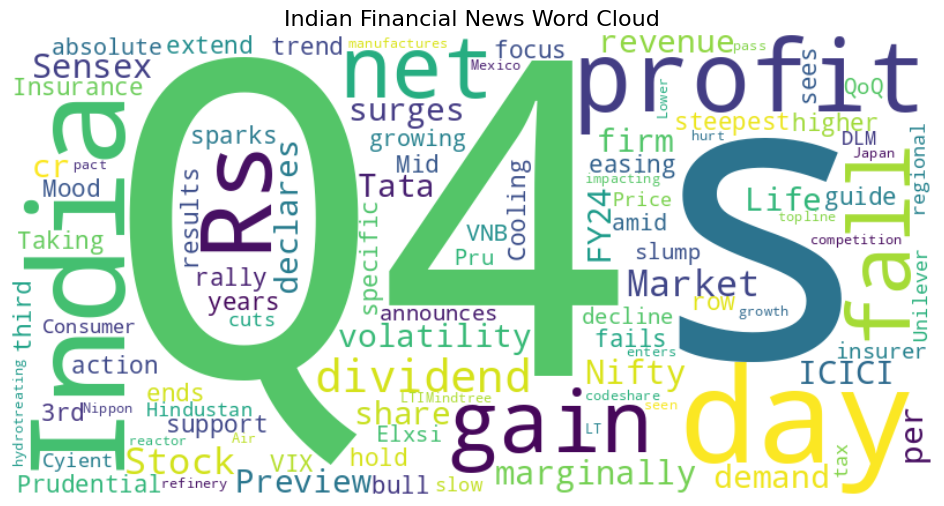

AttributeError: 'VisualizationEngine' object has no attribute 'plot_returns_distribution'

In [11]:
# ============================================================================
# RUN THE PIPELINE
# ============================================================================

if __name__ == "__main__":
    # Execute the main pipeline
    results_dict = main()

    # Save results for further analysis
    print("\nSaving results...")

    # Save predictions
    predictions_df = pd.DataFrame({
        'predicted_direction': results_dict['results']['predictions']['directions'],
        'predicted_return': results_dict['results']['predictions']['returns'],
        'actual_return': results_dict['processed_data']['Target_Return'].values[
            results_dict['trainer'].seq_len + int(len(results_dict['processed_data']) * 0.85):
        ][:len(results_dict['results']['predictions']['directions'])]
    })

    predictions_df.to_csv('finfusion_predictions.csv', index=False)
    print("Predictions saved to 'finfusion_predictions.csv'")

    # Print summary statistics
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)

    print(f"\nModel Accuracy: {results_dict['results']['accuracy']:.4f}")
    print(f"Mean Squared Error: {results_dict['results']['mse']:.6f}")
    print(f"Mean Absolute Error: {results_dict['results']['mae']:.6f}")

    # Calculate additional metrics
    predictions = results_dict['results']['predictions']
    actual_directions = results_dict['processed_data']['Target_Direction'].values[
        results_dict['trainer'].seq_len + int(len(results_dict['processed_data']) * 0.85):
    ][:len(predictions['directions'])]

    precision = (predictions['directions'] == actual_directions).sum() / len(predictions['directions'])
    recall = (predictions['directions'] == actual_directions).sum() / (actual_directions == 1).sum()
    f1_score = 2 * (precision * recall) / (precision + recall)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")